
#### import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("university_raw_data.csv")
df.head(5)

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


In [5]:
df.columns

Index(['RANK_2025', 'RANK_2024', 'Institution_Name', 'Location', 'Region',
       'SIZE', 'FOCUS', 'RES.', 'STATUS', 'Academic_Reputation_Score',
       'Academic_Reputation_Rank', 'Employer_Reputation_Score',
       'Employer_Reputation_Rank', 'Faculty_Student_Score',
       'Faculty_Student_Rank', 'Citations_per_Faculty_Score',
       'Citations_per_Faculty_Rank', 'International_Faculty_Score',
       'International_Faculty_Rank', 'International_Students_Score',
       'International_Students_Rank', 'International_Research_Network_Score',
       'International_Research_Network_Rank', 'Employment_Outcomes_Score',
       'Employment_Outcomes_Rank', 'Sustainability_Score',
       'Sustainability_Rank', 'Overall_Score'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   str    
 1   RANK_2024                             1482 non-null   str    
 2   Institution_Name                      1503 non-null   str    
 3   Location                              1503 non-null   str    
 4   Region                                1503 non-null   str    
 5   SIZE                                  1503 non-null   str    
 6   FOCUS                                 1503 non-null   str    
 7   RES.                                  1503 non-null   str    
 8   STATUS                                1466 non-null   str    
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   str    
 11  Employer_Reputation_Score   

In [7]:
df.isnull().sum()

RANK_2025                                 0
RANK_2024                                21
Institution_Name                          0
Location                                  0
Region                                    0
SIZE                                      0
FOCUS                                     0
RES.                                      0
STATUS                                   37
Academic_Reputation_Score                 0
Academic_Reputation_Rank                  0
Employer_Reputation_Score                 0
Employer_Reputation_Rank                  0
Faculty_Student_Score                     0
Faculty_Student_Rank                      0
Citations_per_Faculty_Score               0
Citations_per_Faculty_Rank                0
International_Faculty_Score             100
International_Faculty_Rank              100
International_Students_Score             58
International_Students_Rank              58
International_Research_Network_Score      1
International_Research_Network_R

In [8]:
null_count = df.isnull().sum().sum()
null_per = (df.isnull().sum().sum() / df.size) * 100

print("Total null values:", null_count)
print("Percentage of Null value:", null_per)

Total null values: 1316
Percentage of Null value: 3.1270791749833666


In [9]:
cols_to_keep = [
    "Institution_Name",
    "Location",
    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS",
    "RANK_2025",
    "RANK_2024",
    "Overall_Score",
    "Academic_Reputation_Score",
    "Employer_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score",
    "Sustainability_Score",
]
df_cleaned = df[cols_to_keep].copy()

In [10]:
df_cleaned.columns

Index(['Institution_Name', 'Location', 'Region', 'SIZE', 'FOCUS', 'RES.',
       'STATUS', 'RANK_2025', 'RANK_2024', 'Overall_Score',
       'Academic_Reputation_Score', 'Employer_Reputation_Score',
       'Faculty_Student_Score', 'Citations_per_Faculty_Score',
       'International_Faculty_Score', 'International_Students_Score',
       'International_Research_Network_Score', 'Employment_Outcomes_Score',
       'Sustainability_Score'],
      dtype='str')

In [11]:
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace({" ": "_","_score":"",".":""}).str.strip()

In [12]:
df_cleaned.columns

Index(['institution_name', 'location', 'region', 'size', 'focus', 'res',
       'status', 'rank_2025', 'rank_2024', 'overall', 'academic_reputation',
       'employer_reputation', 'faculty_student', 'citations_per_faculty',
       'international_faculty', 'international_students',
       'international_research_network', 'employment_outcomes',
       'sustainability'],
      dtype='str')

In [13]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   institution_name                1503 non-null   str    
 1   location                        1503 non-null   str    
 2   region                          1503 non-null   str    
 3   size                            1503 non-null   str    
 4   focus                           1503 non-null   str    
 5   res                             1503 non-null   str    
 6   status                          1466 non-null   str    
 7   rank_2025                       1503 non-null   str    
 8   rank_2024                       1482 non-null   str    
 9   overall                         601 non-null    str    
 10  academic_reputation             1503 non-null   float64
 11  employer_reputation             1503 non-null   float64
 12  faculty_student                 1503 non-null

In [14]:
null_count = df_cleaned.isnull().sum().sum()
null_per = (df_cleaned.isnull().sum().sum() / df.size) * 100

print("Total null values:", null_count)
print("Percentage of Null value:", null_per)

Total null values: 1138
Percentage of Null value: 2.7041155783670754


In [15]:
df_cleaned[df_cleaned.duplicated()]

,institution_name,location,region,size,focus,res,status,rank_2025,rank_2024,overall,academic_reputation,employer_reputation,faculty_student,citations_per_faculty,international_faculty,international_students,international_research_network,employment_outcomes,sustainability


In [16]:
miss_columns = [i for i in df_cleaned.columns if df_cleaned[i].isnull().sum() > 0]
df_cleaned[miss_columns].isnull().sum()

status                             37
rank_2024                          21
overall                           902
international_faculty             100
international_students             58
international_research_network      1
sustainability                     19
dtype: int64

In [17]:
df_cleaned[miss_columns].isnull().sum() / df_cleaned.shape[0] *100 

status                             2.461743
rank_2024                          1.397206
overall                           60.013307
international_faculty              6.653360
international_students             3.858949
international_research_network     0.066534
sustainability                     1.264138
dtype: float64

In [18]:
miss_col = [i for i in df_cleaned.columns if df_cleaned[i].isnull().mean() > 0 and df_cleaned[i].isnull().mean() < 0.05]
miss_col

['status',
 'rank_2024',
 'international_students',
 'international_research_network',
 'sustainability']

In [19]:
df_cleaned['status'].value_counts()

status
A    1165
B     249
C      52
Name: count, dtype: int64

In [20]:
df_cleaned['status'] = df_cleaned['status'].replace({ 'A':'Public' , 'B':'Private','C':'Semi-Autonomous'}, inplace = True)

In [21]:
df_cleaned['status'].value_counts()

status
Public             1165
Private             249
Semi-Autonomous      52
Name: count, dtype: int64

In [22]:
df_cleaned['status'].isnull().sum()

37

In [23]:
df_cleaned['status'] = df_cleaned['status'].fillna(df_cleaned['status'].mode()[0], inplace = True)

In [24]:
print('Null value',df_cleaned['status'].isnull().sum())
df_cleaned['status'].value_counts()

Null value 0


status
Public             1202
Private             249
Semi-Autonomous      52
Name: count, dtype: int64

In [25]:
df_cleaned['rank_2024'].value_counts().head(5)

rank_2024
1201-1400    206
1001-1200    199
1401+         78
951-1000      54
801-850       52
Name: count, dtype: int64

In [26]:
df_cleaned['rank_2025'].value_counts().head(5)

rank_2025
1201-1400    199
1001-1200    197
1401+        102
951-1000      53
901-950       51
Name: count, dtype: int64

In [27]:
df_cleaned['rank_2024'] = df_cleaned['rank_2024'].astype(str).str.strip().str.extract(r"(\d+)").astype(float)
df_cleaned['rank_2025'] = df_cleaned['rank_2025'].astype(str).str.strip().str.extract(r"(\d+)").astype(float)

In [28]:
df_cleaned['rank_2024'].value_counts(5)

rank_2024
1201.0    0.139001
1001.0    0.134278
1401.0    0.052632
951.0     0.036437
801.0     0.035088
            ...   
480.0     0.000675
479.0     0.000675
290.0     0.000675
525.0     0.000675
555.0     0.000675
Name: proportion, Length: 378, dtype: float64

In [29]:
df_cleaned['rank_2025'].value_counts(5)

rank_2025
1201.0    0.132402
1001.0    0.131071
1401.0    0.067864
951.0     0.035263
901.0     0.033932
            ...   
202.0     0.000665
534.0     0.000665
564.0     0.000665
573.0     0.000665
595.0     0.000665
Name: proportion, Length: 388, dtype: float64

Text(0.5, 1.0, 'Rank_2024 Distribution')

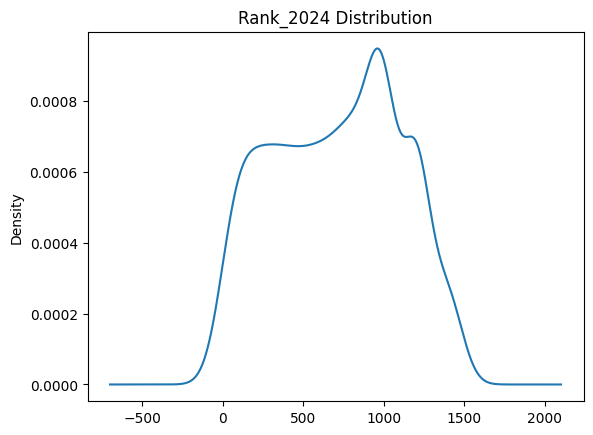

In [30]:
df_cleaned['rank_2024'].plot(kind='kde')
plt.title('Rank_2024 Distribution')

In [31]:
df_cleaned['rank_2024'] = df_cleaned['rank_2024'].fillna(df_cleaned['rank_2024'].mean(), inplace=True)
df_cleaned['rank_2024'].isnull().sum()

0

In [32]:
df_cleaned['rank_update'] = df_cleaned['rank_2024'] - df_cleaned['rank_2025']

In [33]:
df_cleaned['rank_update'].head(6)

0    0.0
1    4.0
2    0.0
3    0.0
4   -3.0
5   -1.0
Name: rank_update, dtype: float64

In [34]:
df_cleaned['international_research_network'].isnull().sum()

1

In [35]:
inter_res_mean = df_cleaned['international_research_network'].mean()

In [36]:
df_cleaned['international_research_network'] = df_cleaned['international_research_network'].fillna(inter_res_mean, inplace= True)

In [37]:
df_cleaned['international_research_network'].isnull().sum()

0

In [38]:
df_cleaned.isnull().sum()

institution_name                    0
location                            0
region                              0
size                                0
focus                               0
res                                 0
status                              0
rank_2025                           0
rank_2024                           0
overall                           902
academic_reputation                 0
employer_reputation                 0
faculty_student                     0
citations_per_faculty               0
international_faculty             100
international_students             58
international_research_network      0
employment_outcomes                 0
sustainability                     19
rank_update                         0
dtype: int64

Text(0.5, 1.0, 'Sustainability Distribution')

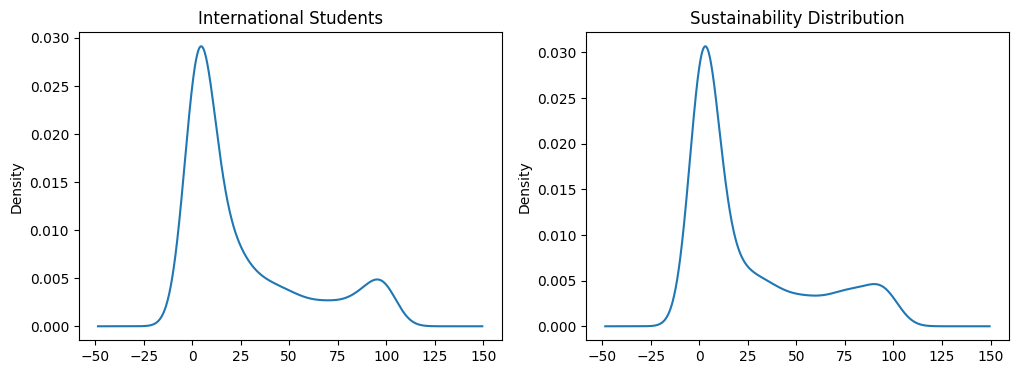

In [39]:
plt.figure(figsize = (12,4))
plt.subplot(121)
df_cleaned['international_students'].plot(kind='kde')
plt.title('International Students')

plt.subplot(122)
df_cleaned['sustainability'].plot(kind='kde')
plt.title('Sustainability Distribution')

In [40]:
df_cleaned['international_students'] = df_cleaned['international_students'].fillna(df_cleaned['international_students'].median(), inplace=True)

In [41]:
df_cleaned['international_students'].isnull().sum()

0

In [42]:
df_cleaned['sustainability'] = df_cleaned['sustainability'].fillna(df_cleaned['sustainability'].median(), inplace=True)

In [43]:
df_cleaned['sustainability'].isnull().sum()

0

In [44]:
miss_col = [i for i in df_cleaned.columns if df_cleaned[i].isnull().mean() > 0 and df_cleaned[i].isnull().mean() < 0.05]
miss_col

[]

In [45]:
miss_col = [i for i in df_cleaned.columns if df_cleaned[i].isnull().mean() > 0.05]
miss_col

['overall', 'international_faculty']

In [46]:
df_cleaned['overall'].isnull().sum() / len(df_cleaned) * 100

60.01330671989354

In [47]:
df_cleaned['overall'] 

0        100
1       98.5
2       96.9
3       96.8
4       96.7
        ... 
1498     NaN
1499     NaN
1500     NaN
1501     NaN
1502     NaN
Name: overall, Length: 1503, dtype: str

In [48]:
# 3. Clean 'qs_overall_score' (convert '-' to NaN and cast to float)
df_cleaned["overall"] = pd.to_numeric(df_cleaned["overall"], errors="coerce")

Text(0.5, 1.0, 'Internationalfacult')

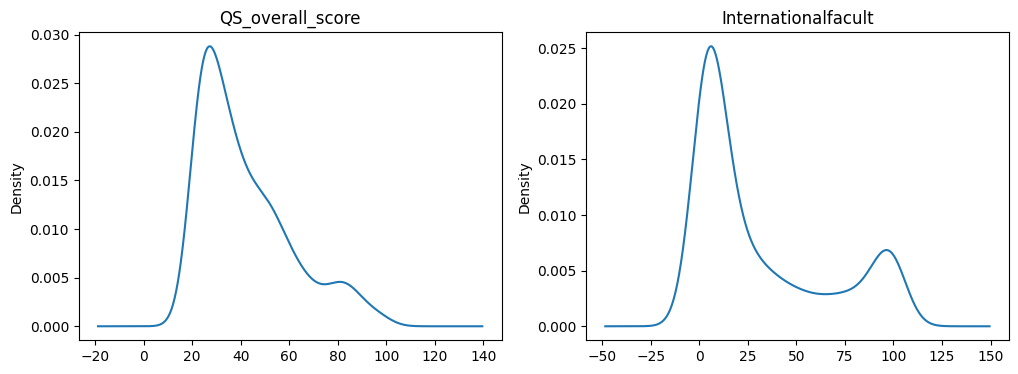

In [49]:
plt.figure(figsize = (12,4))
plt.subplot(121)
df_cleaned['overall'].plot(kind='kde')
plt.title('QS_overall_score')

plt.subplot(122)
df_cleaned['international_faculty'].plot(kind='kde')
plt.title('Internationalfacult')


In [50]:
inter_fac_median = df_cleaned["international_faculty"].median()
df_cleaned["international_faculty"] = df_cleaned["international_faculty"].fillna(inter_fac_median,inplace=True)

In [51]:
# QS Official Weighting Methodology
weights = {
    "academic_reputation": 0.30,  # 30%
    "citations_per_faculty": 0.20,  # 20%
    "employer_reputation": 0.15,  # 15%
    "faculty_student": 0.10,  # 10%
    "international_faculty": 0.05,  # 5%
    "international_students": 0.05,  # 5%
    "international_research_network": 0.05,  # 5%
    "employment_outcomes": 0.05,  # 5%
    "sustainability": 0.05,  # 5%
}

# 1. Calculate the theoretical weighted score
calculated_score = sum(
    df_cleaned[col].astype(float) * weight for col, weight in weights.items()
)

In [52]:
# 2. Fill missing overall values with calculated composite score
df_cleaned["overall"] = df_cleaned["overall"].fillna(
    calculated_score.round(2)
)

In [53]:
df_cleaned.isnull().sum()

institution_name                  0
location                          0
region                            0
size                              0
focus                             0
res                               0
status                            0
rank_2025                         0
rank_2024                         0
overall                           0
academic_reputation               0
employer_reputation               0
faculty_student                   0
citations_per_faculty             0
international_faculty             0
international_students            0
international_research_network    0
employment_outcomes               0
sustainability                    0
rank_update                       0
dtype: int64

In [54]:
null_count = df_cleaned.isnull().sum().sum()
null_per = (df_cleaned.isnull().sum().sum() / df.size) * 100

print("Total null values:", null_count)
print("Percentage of Null value:", null_per)

Total null values: 0
Percentage of Null value: 0.0


In [55]:
df_cleaned["institution_name"] = df_cleaned["institution_name"].str.strip()

In [56]:
df_cleaned['institution_name'].value_counts()

institution_name
Massachusetts Institute of Technology (MIT)    1
Imperial College London                        1
University of Oxford                           1
Harvard University                             1
University of Cambridge                        1
                                              ..
University of Montana Missoula                 1
University of Oradea                           1
University of San Carlos                       1
University Politehnica of Timisoara, UPT       1
Western Washington University                  1
Name: count, Length: 1503, dtype: int64

In [195]:
df_cleaned['institution_name'].nunique()

1503

In [189]:
df_cleaned['institution_name'] = df_cleaned['institution_name'].astype('str').str.replace(","," ").str.strip()

In [191]:
df_cleaned['institution_name'].value_counts()

institution_name
Massachusetts Institute of Technology (MIT)    1
Imperial College London                        1
University of Oxford                           1
Harvard University                             1
University of Cambridge                        1
                                              ..
University of Montana Missoula                 1
University of Oradea                           1
University of San Carlos                       1
University Politehnica of Timisoara  UPT       1
Western Washington University                  1
Name: count, Length: 1503, dtype: int64

In [193]:
df_cleaned.groupby('institution_name').filter(lambda x: x['institution_name'].count() > 1)

,institution_name,location,region,size,focus,res,status,rank_2025,rank_2024,overall,academic_reputation,employer_reputation,faculty_student,citations_per_faculty,international_faculty,international_students,international_research_network,employment_outcomes,sustainability,rank_update


In [167]:
df_cleaned["location"] = df_cleaned["location"].str.strip()

In [169]:
df_cleaned['location'].value_counts()

location
United States             197
United Kingdom             90
China (Mainland)           71
Japan                      49
Germany                    48
                         ... 
Sudan                       1
Bosnia and Herzegovina      1
Syrian Arab Republic        1
Guatemala                   1
Honduras                    1
Name: count, Length: 106, dtype: int64

In [61]:
df_cleaned['location'].value_counts()

location
United States             197
United Kingdom             90
China (Mainland)           71
Japan                      49
Germany                    48
                         ... 
Sudan                       1
Bosnia and Herzegovina      1
Syrian Arab Republic        1
Guatemala                   1
Honduras                    1
Name: count, Length: 106, dtype: int64

In [62]:
df_cleaned['location'].nunique()

106

In [63]:
df_cleaned['region'].value_counts()

region
Asia              501
Europe            497
Americas          418
Oceania            46
Africa             40
Not Classified      1
Name: count, dtype: int64

In [64]:
df_cleaned[df_cleaned['region']=='Not Classified']


,institution_name,location,region,size,focus,res,status,rank_2025,rank_2024,overall,academic_reputation,employer_reputation,faculty_student,citations_per_faculty,international_faculty,international_students,international_research_network,employment_outcomes,sustainability,rank_update
616,Eastern Mediterranean University,Northern Cyprus,Not Classified,L,FC,MD,Public,611.0,708.524966,21.2,5.6,2.1,3.5,26.5,90.1,100.0,55.2,24.1,1.8,97.524966


In [65]:
df_cleaned['region'] = df_cleaned['region'].astype(str).str.strip().replace({"Not Classified": "Asia", "not classified": "Asia"})

In [66]:
df_cleaned['region'].value_counts()

region
Asia        502
Europe      497
Americas    418
Oceania      46
Africa       40
Name: count, dtype: int64

In [67]:
df_cleaned['size'].value_counts()

size
L     691
M     372
XL    352
S      88
Name: count, dtype: int64

In [68]:
df_cleaned['size'] = df_cleaned['size'].replace({ 'L':'Large' , 'M':'Medium','XL':'Extra Large','S':'Small'}, inplace = True)

In [69]:
df_cleaned['size'].value_counts()

size
Large          691
Medium         372
Extra Large    352
Small           88
Name: count, dtype: int64

In [70]:
df_cleaned['focus'].value_counts()

focus
FC    592
CO    480
FO    353
SP     78
Name: count, dtype: int64

In [71]:
df_cleaned['focus'] = df_cleaned['focus'].replace({ 'FC':'Full Comprehensive' , 'CO':'Comprehensive','FO':'Foucsed','SP':'Specialist'}, inplace = True)

In [72]:
df_cleaned['focus'].value_counts()

focus
Full Comprehensive    592
Comprehensive         480
Foucsed               353
Specialist             78
Name: count, dtype: int64

In [73]:
df_cleaned['res'].value_counts()

res
VH    1021
HI     362
MD     104
LO      16
Name: count, dtype: int64

In [74]:
df_cleaned['res'] = df_cleaned['res'].replace({ 'VH':'Very High' , 'HI':'High','MD':'Medium','LO':'Low'}, inplace = True)

In [75]:
df_cleaned['res'].value_counts()

res
Very High    1021
High          362
Medium        104
Low            16
Name: count, dtype: int64

In [76]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   institution_name                1503 non-null   str    
 1   location                        1503 non-null   str    
 2   region                          1503 non-null   str    
 3   size                            1503 non-null   str    
 4   focus                           1503 non-null   str    
 5   res                             1503 non-null   str    
 6   status                          1503 non-null   str    
 7   rank_2025                       1503 non-null   float64
 8   rank_2024                       1503 non-null   float64
 9   overall                         1503 non-null   float64
 10  academic_reputation             1503 non-null   float64
 11  employer_reputation             1503 non-null   float64
 12  faculty_student                 1503 non-null

In [159]:
df_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
rank_2025,1503.0,716.898869,399.086239,1.000000,376.00,741.00,1001.00,1401.0
rank_2024,1503.0,708.524966,391.021360,1.000000,375.00,731.00,1001.00,1401.0
overall,1503.0,23.973320,19.210081,2.960000,10.42,17.92,31.15,100.0
academic_reputation,1503.0,20.286693,22.326168,1.300000,6.30,11.00,23.50,100.0
employer_reputation,1503.0,19.787292,23.784738,1.100000,4.30,9.40,25.30,100.0
faculty_student,1503.0,28.128676,27.613017,1.000000,7.30,16.00,40.40,100.0
citations_per_faculty,1503.0,23.503460,27.870692,1.000000,2.80,9.90,36.40,100.0
international_faculty,1503.0,29.523353,33.491395,1.000000,4.60,12.50,46.55,100.0
international_students,1503.0,24.963673,30.647403,1.000000,3.10,9.60,36.95,100.0
international_research_network,1503.0,50.129095,29.856644,1.000000,22.75,51.10,77.10,100.0


In [197]:
#df_cleaned.to_csv("university_cleaned.csv", index=False)